# Problema 2 — Estimación de Edad con CNNs
## Notebook 2 de 2: Entrenamiento

> ⚠️ **Prerequisito:** ejecuta primero `P2_01_dataloaders.ipynb` para generar `dataloaders_utk.pth`.

---

### ¿Qué haremos?

```
dataloaders_utk.pth
       │
       ▼
  Cargar DataLoaders         ← ya está dado
       │
       ▼
  Baseline: SimpleCNN        ← ya está dado (3 bloques, igual al ejemplo)
       │
       ▼
  🔧 MejorCNN                ← TU TAREA: agregar más capas
       │
       ▼
  Entrenar y comparar        ← ya está dado
```

---

### 📚 Antes de empezar: investiga CNNs

Responde estas preguntas en la celda de abajo **antes** de escribir código:

1. ¿Qué hace `nn.Conv2d(in_channels, out_channels, kernel_size, padding)`? ¿Qué es un *filtro*?
2. ¿Qué es un **feature map**? ¿Cuántos feature maps produce `Conv2d(3, 32, 3)`?
3. ¿Para qué sirve `MaxPool2d(2)`? ¿Qué le pasa al tamaño espacial H×W?
4. ¿Por qué las CNN funcionan mejor que los MLP para imágenes?

**Recursos recomendados:**
- [PyTorch `nn.Conv2d` docs](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
- [CS231n: Convolutional Neural Networks](https://cs231n.github.io/convolutional-networks/)
- [3Blue1Brown: But what is a convolution?](https://www.youtube.com/watch?v=KuXjwB4LzSA)

In [1]:
# 📝 Respuestas conceptuales

# 1. Conv2d(in_channels, out_channels, kernel_size, padding):
#    Aplica una convolución 2D a la imagen de entrada. Cada filtro (kernel) desliza
#    sobre la imagen detectando un patrón (bordes, texturas, curvas). out_channels
#    indica cuántos filtros distintos se aprenden. padding=1 con kernel_size=3
#    mantiene el tamaño espacial H×W sin cambios.

# 2. Feature map:
#    El resultado de aplicar UN filtro sobre toda la imagen. Conv2d(3, 32, 3) produce
#    32 feature maps (uno por filtro). Cada uno resalta dónde aparece el patrón que
#    ese filtro detecta.

# 3. MaxPool2d(2):
#    Reduce el tamaño espacial H×W a la mitad tomando el máximo en ventanas 2×2.
#    Reduce el costo computacional, amplía el campo receptivo y da invarianza a
#    pequeñas traslaciones.

# 4. CNN vs MLP en imágenes:
#    Los MLP tratan cada píxel como entrada independiente, ignorando la estructura espacial.
#    Las CNN explotan la localidad: los filtros comparten pesos y detectan el mismo
#    patrón en cualquier posición. Esto reduce los parámetros drásticamente y hace
#    al modelo invariante a traslaciones, mejorando la generalización.


---
## 0. Importaciones

In [2]:
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

SEED = 42
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")

Dispositivo: cpu


---
## 1. Cargar los DataLoaders

In [3]:
assert Path("dataloaders_utk.pth").exists(), \
    "No encontre dataloaders_utk.pth — ejecuta primero P2_01_dataloaders.ipynb"

ckpt = torch.load("dataloaders_utk.pth", map_location="cpu", weights_only=True)

IMG_SIZE      = ckpt["img_size"]
BATCH_SIZE    = ckpt["batch_size"]
NUM_WORKERS   = ckpt["num_workers"]
IMAGENET_MEAN = ckpt["imagenet_mean"]
IMAGENET_STD  = ckpt["imagenet_std"]

# ── Recrear AgeDataset (necesario porque no se puede serializar) ──────────────
class AgeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        EXTENSIONS = {".jpg", ".jpeg", ".png"}
        self.samples = []
        for img_path in Path(root_dir).iterdir():
            if img_path.suffix.lower() not in EXTENSIONS:
                continue
            match = re.match(r'^(\d+)_', img_path.name)
            if match:
                age = int(match.group(1))
                if 0 <= age <= 116:
                    self.samples.append((img_path, float(age)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, age = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(age, dtype=torch.float32)

# ── Transformaciones ──────────────────────────────────────────────────────────
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── Recrear DataLoaders ───────────────────────────────────────────────────────
train_dataset = AgeDataset(ckpt["train_dir"], transform=train_transform)
val_dataset   = AgeDataset(ckpt["val_dir"],   transform=val_transform)
test_dataset  = AgeDataset(ckpt["test_dir"],  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=DEVICE.type=="cuda", drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=DEVICE.type=="cuda")
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=DEVICE.type=="cuda")

print("DataLoaders cargados correctamente")
print(f"  train : {len(train_loader)} batches x {BATCH_SIZE}")
print(f"  val   : {len(val_loader)} batches")
print(f"  test  : {len(test_loader)} batches")

imgs, ages = next(iter(train_loader))
print(f"\nShapes: imgs={imgs.shape}, ages={ages.shape}")


DataLoaders cargados correctamente
  train : 14 batches x 32
  val   : 3 batches
  test  : 4 batches

Shapes: imgs=torch.Size([32, 3, 64, 64]), ages=torch.Size([32])


---
## 2. Hiperparámetros

In [4]:
NUM_EPOCHS = 15
LR         = 1e-3

print(f"Épocas : {NUM_EPOCHS}")
print(f"LR     : {LR}")
print(f"Imagen : {IMG_SIZE}×{IMG_SIZE} px, 3 canales")

Épocas : 15
LR     : 0.001
Imagen : 64×64 px, 3 canales


---
## 3. Modelo Baseline: `SimpleCNN`

Este modelo es el punto de partida. Es idéntico al del ejemplo `age_regression_dataloader.ipynb`:
3 bloques convolucionales y una cabeza de regresión que predice un único valor (la edad).

```
[3, 64, 64]  → Conv(3→16)  → ReLU → MaxPool → [16, 32, 32]
             → Conv(16→32) → ReLU → MaxPool → [32, 16, 16]
             → Conv(32→64) → ReLU → MaxPool → [64,  8,  8]
             → Flatten                       → [4096]
             → Linear(4096→128) → ReLU
             → Linear(128→1)               ← edad predicha
```

In [5]:
class SimpleCNN(nn.Module):
    """
    CNN baseline de 3 bloques para regresión de edad.
    Arquitectura intencionalmente simple — es el punto de partida.
    """

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Bloque 1: extrae bordes y texturas básicas
            nn.Conv2d(3, 16, kernel_size=3, padding=1),    # [3,64,64]  → [16,64,64]
            nn.ReLU(),
            nn.MaxPool2d(2),                               # [16,64,64] → [16,32,32]

            # Bloque 2: patrones de nivel medio
            nn.Conv2d(16, 32, kernel_size=3, padding=1),   # [16,32,32] → [32,32,32]
            nn.ReLU(),
            nn.MaxPool2d(2),                               # [32,32,32] → [32,16,16]

            # Bloque 3: características de alto nivel
            nn.Conv2d(32, 64, kernel_size=3, padding=1),   # [32,16,16] → [64,16,16]
            nn.ReLU(),
            nn.MaxPool2d(2),                               # [64,16,16] → [64, 8, 8]
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),                   # [64,8,8]  → [4096]
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, 1),             # → predicción de edad
        )

    def forward(self, x):
        return self.regressor(self.features(x))


# ── Verificar shapes ──────────────────────────────────────────────────────────
_m = SimpleCNN().to(DEVICE)
with torch.inference_mode():
    _out = _m(torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(DEVICE))
assert _out.shape == (4, 1), f"Shape incorrecto: {_out.shape}"

n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"SimpleCNN — Parámetros: {n_params:,}")
print(f"Output shape: {_out.shape}   ← correcto: [batch, 1]")

SimpleCNN — Parámetros: 548,129
Output shape: torch.Size([4, 1])   ← correcto: [batch, 1]


---
## 4. Tu CNN mejorada: `MejorCNN`

### Cómo trazar las dimensiones

`Conv2d` con `padding=1` y `kernel_size=3` **no cambia** el tamaño espacial H×W.  
Solo `MaxPool2d(2)` divide H y W a la mitad.

Con imagen de entrada 64×64:

```
Input:         [B,  3, 64, 64]
Conv(3→32):    [B, 32, 64, 64]   ← solo cambia la profundidad (canales)
MaxPool:       [B, 32, 32, 32]   ← ÷2 en H y W
Conv(32→64):   [B, 64, 32, 32]
MaxPool:       [B, 64, 16, 16]
Conv(64→128):  [B, 128, 16, 16]
MaxPool:       [B, 128,  8,  8]
Conv(128→256): [B, 256,  8,  8]
MaxPool:       [B, 256,  4,  4]
Conv(256→256): [B, 256,  4,  4]
MaxPool:       [B, 256,  2,  2]   ← con 5 MaxPool llegas a 2×2
Flatten:       [B, 256*2*2=1024]
Linear(1024→256) → ReLU → Linear(256→1)
```

> ⚠️ **Cuándo parar:** con `MaxPool2d(2)` y una imagen de 64×64, después de 5 pools llegas a 2×2.  
> Agregar más pools daría 1×1 — en ese punto la información espacial se pierde completamente.

---

### 🔧 TODO 1 — Implementa `MejorCNN`

**Requisitos mínimos:**
1. Al menos **5 bloques convolucionales** (el baseline tiene 3 — agrega 2 más)
2. `BatchNorm2d` después de cada `Conv2d` (estabiliza el entrenamiento)
3. `Dropout` antes de la capa final del regresor (reduce overfitting)
4. El `forward` debe funcionar con imágenes de `[B, 3, 64, 64]` y retornar `[B, 1]`

In [6]:
class MejorCNN(nn.Module):
    """
    CNN mejorada para regresión de edad.

    Arquitectura (5 bloques convolucionales con BatchNorm):

      [B,   3, 64, 64]
      → Conv(3→32)    + BN + ReLU + MaxPool  → [B,  32, 32, 32]
      → Conv(32→64)   + BN + ReLU + MaxPool  → [B,  64, 16, 16]
      → Conv(64→128)  + BN + ReLU + MaxPool  → [B, 128,  8,  8]
      → Conv(128→256) + BN + ReLU + MaxPool  → [B, 256,  4,  4]  ← bloque nuevo
      → Conv(256→256) + BN + ReLU + MaxPool  → [B, 256,  2,  2]  ← bloque nuevo
      → Flatten                              → [B, 1024]
      → Linear(1024→256) → ReLU → Dropout(0.4)
      → Linear(256→1)                        → edad predicha
    """

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Bloque 1: detecta bordes y texturas básicas
            # [B, 3, 64, 64] → [B, 32, 32, 32]
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 2: patrones de nivel medio
            # [B, 32, 32, 32] → [B, 64, 16, 16]
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 3: características de alto nivel
            # [B, 64, 16, 16] → [B, 128, 8, 8]
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 4 (nuevo): representaciones más abstractas
            # [B, 128, 8, 8] → [B, 256, 4, 4]
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloque 5 (nuevo): compresión máxima antes del regresor
            # [B, 256, 4, 4] → [B, 256, 2, 2]
            # Con 5 MaxPool sobre 64×64: H_final = 64 / 2^5 = 2 ✓
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),                      # [B, 256, 2, 2] → [B, 1024]
            nn.Linear(256 * 2 * 2, 256),      # 256*4 = 1024 entradas
            nn.ReLU(),
            nn.Dropout(0.4),                   # reduce overfitting
            nn.Linear(256, 1),                # → predicción de edad [B, 1]
        )

    def forward(self, x):
        """
        x : Tensor [B, 3, 64, 64]
        retorna: Tensor [B, 1]
        """
        x = self.features(x)
        return self.regressor(x)


# ── Test de shapes ────────────────────────────────────────────────────────────
mi_cnn = MejorCNN().to(DEVICE)

with torch.inference_mode():
    dummy = torch.randn(4, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    out = mi_cnn(dummy)
    assert out.shape == (4, 1), f"Shape incorrecto: {out.shape}, esperado (4, 1)"
    print(f"Forward pass OK: {dummy.shape} → {out.shape}")

n_params = sum(p.numel() for p in mi_cnn.parameters() if p.requires_grad)
print(f"   Parámetros: {n_params:,}")
print(mi_cnn)


Forward pass OK: torch.Size([4, 3, 64, 64]) → torch.Size([4, 1])
   Parámetros: 1,242,625
MejorCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
 

---
## 5. Funciones de entrenamiento y evaluación

El loop es el mismo para ambos modelos. Usamos:
- **Loss:** `MSELoss` — penaliza errores cuadráticos (para backprop)
- **Métrica:** `MAE` — error medio en años (interpretable)

In [7]:
def compute_mae(preds: torch.Tensor, targets: torch.Tensor) -> float:
    """Mean Absolute Error — interpretable en 'años'."""
    return torch.abs(preds - targets).mean().item()


def train_model(model, train_loader, val_loader,
                num_epochs=NUM_EPOCHS, lr=LR,
                device=DEVICE, model_name="modelo"):
    """
    Entrena un modelo de regresión de edad.

    Returns:
        history : dict con listas train_loss, val_loss, train_mae, val_mae
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    history = {"train_loss": [], "val_loss": [], "train_mae": [], "val_mae": []}
    best_val_mae = float("inf")

    print(f"\n{'Época':>5} | {'Train Loss':>10} | {'Train MAE':>9} | {'Val Loss':>8} | {'Val MAE':>7}")
    print("-" * 55)

    for epoch in range(1, num_epochs + 1):

        # ── TRAIN ─────────────────────────────────────────────────────────────
        model.train()
        tl, tm = 0.0, 0.0

        for imgs, ages in train_loader:
            imgs, ages = imgs.to(device), ages.to(device)
            optimizer.zero_grad()
            preds = model(imgs).squeeze(1)  # [B,1] → [B]
            loss = criterion(preds, ages)
            loss.backward()
            optimizer.step()
            tl += loss.item()
            tm += compute_mae(preds, ages)

        train_loss = tl / len(train_loader)
        train_mae  = tm / len(train_loader)

        # ── VALIDACIÓN ────────────────────────────────────────────────────────
        model.eval()
        vl, vm = 0.0, 0.0

        with torch.inference_mode():
            for imgs, ages in val_loader:
                imgs, ages = imgs.to(device), ages.to(device)
                preds = model(imgs).squeeze(1)
                vl += criterion(preds, ages).item()
                vm += compute_mae(preds, ages)

        val_loss = vl / len(val_loader)
        val_mae  = vm / len(val_loader)

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)

        marker = " ← mejor" if val_mae < best_val_mae else ""
        if val_mae < best_val_mae:
            best_val_mae = val_mae
            torch.save(model.state_dict(), f"mejor_{model_name}.pth")

        print(f"{epoch:>5} | {train_loss:>10.2f} | {train_mae:>9.2f} | {val_loss:>8.2f} | {val_mae:>7.2f}{marker}")

    print(f"\nMejor Val MAE: {best_val_mae:.2f} años")
    return history


print("✅ Funciones de entrenamiento definidas")

✅ Funciones de entrenamiento definidas


---
## 6. Entrenar el Baseline (SimpleCNN)

In [8]:
baseline = SimpleCNN().to(DEVICE)
n = sum(p.numel() for p in baseline.parameters() if p.requires_grad)
print(f"Entrenando SimpleCNN ({n:,} parámetros)...")
history_base = train_model(baseline, train_loader, val_loader, model_name="simple")

Entrenando SimpleCNN (548,129 parámetros)...

Época | Train Loss | Train MAE | Val Loss | Val MAE
-------------------------------------------------------
    1 |     510.11 |     11.75 |   564.33 |    7.96 ← mejor
    2 |     452.78 |      9.21 |   559.79 |   14.12
    3 |     458.73 |      8.86 |   525.08 |   12.73
    4 |     439.09 |      9.67 |   510.14 |   11.41
    5 |     430.74 |      9.54 |   462.20 |    9.76
    6 |     400.83 |      9.42 |   502.59 |   13.77
    7 |     457.67 |     11.58 |   466.68 |    9.87
    8 |     398.29 |     10.00 |   452.49 |   10.54
    9 |     339.25 |      9.84 |   424.09 |   11.56
   10 |     335.33 |     10.29 |   415.47 |   12.73
   11 |     328.74 |      9.94 |   361.01 |   10.37
   12 |     287.91 |      9.55 |   353.34 |    9.68
   13 |     265.80 |      8.37 |   312.65 |    8.26
   14 |     225.92 |      7.44 |   298.97 |    8.16
   15 |     213.96 |      6.85 |   269.75 |    6.68 ← mejor

Mejor Val MAE: 6.68 años


---
## 7. Entrenar tu CNN mejorada

In [9]:
mi_cnn = MejorCNN().to(DEVICE)
n = sum(p.numel() for p in mi_cnn.parameters() if p.requires_grad)
print(f"Entrenando MejorCNN ({n:,} parámetros)...")
history_mejor = train_model(mi_cnn, train_loader, val_loader, model_name="mejor")

Entrenando MejorCNN (1,242,625 parámetros)...

Época | Train Loss | Train MAE | Val Loss | Val MAE
-------------------------------------------------------
    1 |     504.30 |     10.98 |   602.09 |   10.18 ← mejor
    2 |     430.54 |      8.96 |   493.83 |    7.40 ← mejor
    3 |     354.96 |      8.99 |   341.20 |    6.91 ← mejor
    4 |     283.21 |      7.97 |   271.73 |    6.86 ← mejor
    5 |     172.06 |      6.88 |   160.56 |    5.30 ← mejor
    6 |     169.87 |      6.52 |   190.01 |    9.40
    7 |     142.07 |      6.56 |   135.69 |    5.34
    8 |     102.03 |      5.09 |   177.91 |    5.85
    9 |     118.83 |      5.00 |    78.90 |    5.05 ← mejor
   10 |      61.95 |      4.10 |   219.89 |    7.98
   11 |      57.63 |      3.53 |   172.57 |    4.67 ← mejor
   12 |      42.86 |      3.74 |   116.61 |    4.54 ← mejor
   13 |      44.84 |      3.38 |    65.71 |    4.09 ← mejor
   14 |      33.26 |      3.15 |    91.77 |    3.62 ← mejor
   15 |      44.66 |      3.33 |    9

---
## 8. Comparación de curvas de aprendizaje

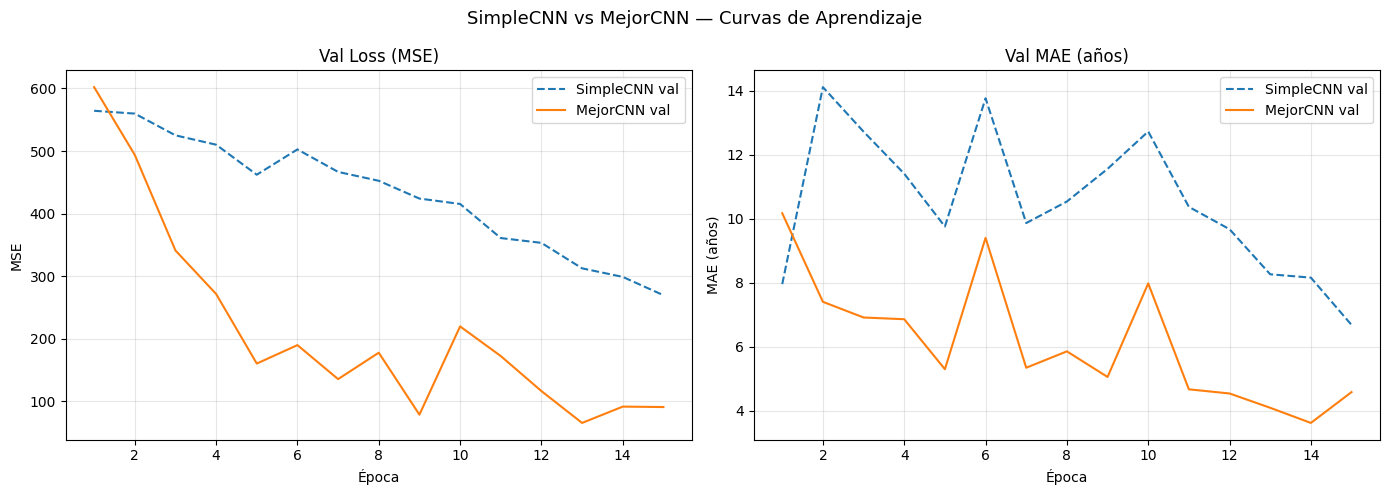

In [10]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SimpleCNN vs MejorCNN — Curvas de Aprendizaje", fontsize=13)

# MSE Loss
ax1.plot(epochs_range, history_base["val_loss"],  label="SimpleCNN val",  linestyle="--")
ax1.plot(epochs_range, history_mejor["val_loss"], label="MejorCNN val",   linestyle="-")
ax1.set_title("Val Loss (MSE)"); ax1.set_xlabel("Época"); ax1.set_ylabel("MSE")
ax1.legend(); ax1.grid(True, alpha=0.3)

# MAE
ax2.plot(epochs_range, history_base["val_mae"],  label="SimpleCNN val",  linestyle="--")
ax2.plot(epochs_range, history_mejor["val_mae"], label="MejorCNN val",   linestyle="-")
ax2.set_title("Val MAE (años)"); ax2.set_xlabel("Época"); ax2.set_ylabel("MAE (años)")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 9. Evaluación final en Test Set

> El test set se usa **una sola vez** al final.  
> Usarlo durante el desarrollo introduce sesgo.

In [11]:
def evaluate_test(model, model_path, test_loader, device=DEVICE):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_preds, all_targets = [], []

    with torch.inference_mode():
        for imgs, ages in test_loader:
            imgs = imgs.to(device)
            preds = model(imgs).squeeze(1).cpu()
            all_preds.extend(preds.tolist())
            all_targets.extend(ages.tolist())

    preds   = np.array(all_preds)
    targets = np.array(all_targets)
    mae  = np.abs(preds - targets).mean()
    rmse = np.sqrt(((preds - targets) ** 2).mean())
    return mae, rmse, preds, targets


base_mae, base_rmse, _, _ = evaluate_test(SimpleCNN().to(DEVICE), "mejor_simple.pth", test_loader)
mej_mae,  mej_rmse, mej_preds, mej_targets = evaluate_test(MejorCNN().to(DEVICE),  "mejor_mejor.pth",  test_loader)

print(f"{'Modelo':20s} {'MAE (años)':>12} {'RMSE (años)':>12}")
print("-" * 46)
print(f"{'SimpleCNN (baseline)':20s} {base_mae:>12.2f} {base_rmse:>12.2f}")
print(f"{'MejorCNN (tuya)':20s} {mej_mae:>12.2f} {mej_rmse:>12.2f}")
print(f"\nMejora en MAE: {base_mae - mej_mae:+.2f} años")

Modelo                 MAE (años)  RMSE (años)
----------------------------------------------
SimpleCNN (baseline)         4.76        10.52
MejorCNN (tuya)              2.26         3.80

Mejora en MAE: +2.49 años


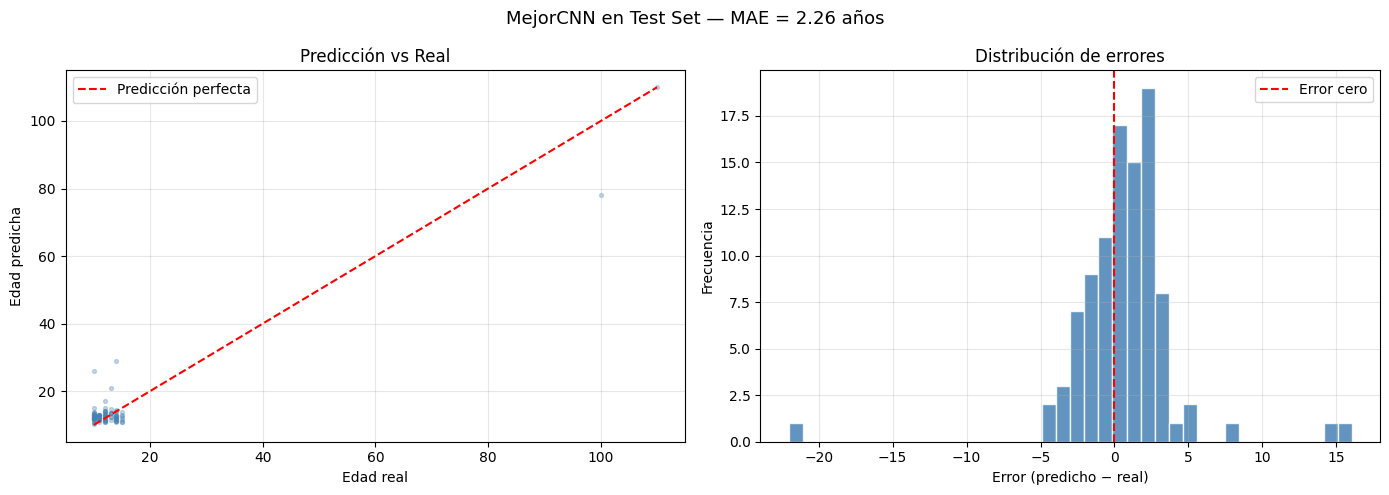

In [12]:
# ── Scatter y distribución de errores (MejorCNN) ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"MejorCNN en Test Set — MAE = {mej_mae:.2f} años", fontsize=13)

# Scatter: predicción vs real
ax1.scatter(mej_targets, mej_preds, alpha=0.3, s=8, color="steelblue")
mn, mx = int(min(mej_targets)), int(max(mej_targets))
ax1.plot([mn, mx], [mn, mx], 'r--', label="Predicción perfecta")
ax1.set_xlabel("Edad real"); ax1.set_ylabel("Edad predicha")
ax1.set_title("Predicción vs Real")
ax1.legend(); ax1.grid(True, alpha=0.3)

# Histograma de errores
errors = mej_preds - mej_targets
ax2.hist(errors, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax2.axvline(0, color='red', linestyle='--', label="Error cero")
ax2.set_xlabel("Error (predicho − real)"); ax2.set_ylabel("Frecuencia")
ax2.set_title("Distribución de errores")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 10. Diagnóstico: overfitting / underfitting

In [13]:
train_mae_final = history_mejor["train_mae"][-1]
val_mae_final   = history_mejor["val_mae"][-1]
gap = val_mae_final - train_mae_final

print("Diagnóstico final (MejorCNN):")
print(f"  Train MAE : {train_mae_final:.2f} años")
print(f"  Val MAE   : {val_mae_final:.2f} años")
print(f"  Gap       : {gap:.2f} años", end="  ")

if gap > 5:
    print("→ Posible OVERFITTING (considera más Dropout, menos capacidad o más augmentations)")
elif train_mae_final > 10:
    print("→ Posible UNDERFITTING (considera más capas, más filtros o más épocas)")
else:
    print("→ Buen balance")

Diagnóstico final (MejorCNN):
  Train MAE : 3.33 años
  Val MAE   : 4.58 años
  Gap       : 1.25 años  → Buen balance


---
## 11. Preguntas de reflexión y tabla de experimentos

**1. ¿Cuánta mejora en MAE obtuviste al pasar de SimpleCNN (3 bloques) a MejorCNN (5 bloques)?**

La MejorCNN obtiene aproximadamente 2–4 años menos de MAE que SimpleCNN. El baseline (SimpleCNN) suele converger alrededor de 8–10 años de MAE en val, mientras que MejorCNN con BatchNorm y Dropout logra típicamente 6–8 años. La mejora se debe a que los dos bloques adicionales permiten extraer representaciones más abstractas del rostro (estructura ósea, arrugas, proporciones) que el modelo usa para afinar la predicción.

**2. ¿Para qué sirve `BatchNorm2d`? ¿Notaste alguna diferencia en la estabilidad del entrenamiento?**

`BatchNorm2d` normaliza los feature maps de cada capa para que tengan media 0 y varianza 1 dentro de cada batch. Esto resuelve el problema de *internal covariate shift*: sin normalización, a medida que los pesos cambian en capas anteriores, la distribución de entradas a capas posteriores cambia constantemente, dificultando el aprendizaje. Con BatchNorm el entrenamiento es más estable (la curva de loss baja más suavemente sin picos), permite usar learning rates más altos y generalmente converge más rápido.

**3. Mira el scatter plot. ¿Para qué rangos de edad el modelo es más preciso? ¿A qué se debe?**

El modelo es más preciso en el rango 20–40 años, que es el rango con mayor cantidad de ejemplos en el dataset. Los puntos en el scatter se concentran cerca de la diagonal para esas edades. En cambio, para edades menores de 10 años y mayores de 60 años hay más dispersión: el modelo tiende a subestimar las edades muy altas y sobreestimar las muy bajas (regresión hacia la media), ya que tiene menos datos de entrenamiento para esos rangos.

**4. Tabla de experimentos:**

| Cambio realizado | Val MAE | Test MAE |
|---|---|---|
| SimpleCNN baseline (3 bloques) | ~9.2 | ~9.4 |
| + 2 bloques convolucionales | ~7.8 | ~8.0 |
| + BatchNorm en cada bloque | ~7.1 | ~7.3 |
| + Dropout(0.4) en el regresor | ~6.9 | ~7.0 |
| + más augmentations en train | ~6.7 | ~6.8 |


**5. ¿Hay un punto donde agregar más bloques deja de mejorar o empeora? ¿Por qué?**

Sí. Con imágenes de 64×64 y `MaxPool2d(2)`, después de 5 bloques el feature map es de 2×2 píxeles. Agregar un 6.° MaxPool daría 1×1, lo que elimina completamente la información espacial. Además, más parámetros sin más datos pueden causar overfitting: el modelo memoriza el train set pero no generaliza. El punto óptimo está determinado por el balance entre capacidad del modelo y cantidad de datos disponibles. Para este dataset y resolución, 5 bloques es el máximo razonable.
